In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    auc
)
from sklearn.utils.multiclass import unique_labels
from sklearn.inspection import permutation_importance

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    StackingClassifier
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
file_path = "S06-hw-dataset-01.csv"
df = pd.read_csv(file_path)

In [3]:
print("Первые 5 строк датасета:")
print(df.head())

Первые 5 строк датасета:
   id     num01     num02     num03     num04     num05     num06     num07  \
0   1 -0.946058 -0.070313  1.824445 -2.754422  0.808865 -0.111094 -0.268950   
1   2 -2.484027  0.739378  1.596908 -2.586479 -0.033225 -3.054412 -4.706908   
2   3  1.522629  7.159635 -0.564903 -4.493110  1.623610  5.450187 -0.974595   
3   4  0.463373 -1.073908  1.752813  0.362786  2.790872  4.082385  0.322283   
4   5  3.188390 -4.701692 -0.689918 -0.448995  0.373821 -3.275363 -1.760931   

      num08     num09  ...     num20     num21     num22     num23     num24  \
0 -3.078210  0.801275  ... -1.616515 -1.989464  1.407390 -0.218362  2.016052   
1 -9.795169  0.145911  ... -1.727040 -0.583997  1.136761  0.285978 -0.310879   
2 -5.189589  1.600591  ...  0.524408  2.022430  1.278358 -0.850547  0.847457   
3  3.390984 -0.033929  ...  2.399834 -1.431576 -0.746987  0.049639  2.414689   
4  0.923689  0.537345  ... -2.183407 -2.896590  2.440343 -1.097168  1.457323   

   cat_contract  ca

In [4]:
print("\nИнформация о датасете:")
print(df.info())



Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             12000 non-null  int64  
 1   num01          12000 non-null  float64
 2   num02          12000 non-null  float64
 3   num03          12000 non-null  float64
 4   num04          12000 non-null  float64
 5   num05          12000 non-null  float64
 6   num06          12000 non-null  float64
 7   num07          12000 non-null  float64
 8   num08          12000 non-null  float64
 9   num09          12000 non-null  float64
 10  num10          12000 non-null  float64
 11  num11          12000 non-null  float64
 12  num12          12000 non-null  float64
 13  num13          12000 non-null  float64
 14  num14          12000 non-null  float64
 15  num15          12000 non-null  float64
 16  num16          12000 non-null  float64
 17  num17          12000 non-n

In [5]:
print("\nБазовые статистики:")
print(df.describe(include='all').T)


Базовые статистики:
                 count         mean          std        min          25%  \
id             12000.0  6000.500000  3464.245950   1.000000  3000.750000   
num01          12000.0     0.013705     2.096534  -8.155181    -1.423844   
num02          12000.0    -0.005278     3.544498 -14.605579    -2.303772   
num03          12000.0    -0.002357     1.004417  -4.374043    -0.685618   
num04          12000.0     0.038404     2.087318  -7.753301    -1.374579   
num05          12000.0    -0.006301     1.007329  -3.999332    -0.676552   
num06          12000.0    -0.865297     3.888966 -15.238402    -3.532054   
num07          12000.0    -0.702877     1.989513  -7.377252    -2.064888   
num08          12000.0    -0.290694     3.455981 -13.853627    -2.597019   
num09          12000.0    -0.008154     0.996677  -3.794637    -0.683959   
num10          12000.0     0.010048     0.991551  -3.744778    -0.650821   
num11          12000.0     0.007073     0.993499  -3.869569    -0.6

In [6]:
if 'target' in df.columns:
    print(f"\nРаспределение таргета ({df['target'].nunique()} классов):")
    print(df['target'].value_counts().sort_index())
else:
    print("\nСтолбец 'target' не найден в датасете!")


Распределение таргета (2 классов):
target
0    8119
1    3881
Name: count, dtype: int64


In [7]:
print("\nПропущенные значения")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0].sort_values(ascending=False))
else:
    print("Пропущенных значений нет.")



Пропущенные значения
Пропущенных значений нет.


In [8]:
print("\nТипы столбцов:")
print(df.dtypes)


Типы столбцов:
id                 int64
num01            float64
num02            float64
num03            float64
num04            float64
num05            float64
num06            float64
num07            float64
num08            float64
num09            float64
num10            float64
num11            float64
num12            float64
num13            float64
num14            float64
num15            float64
num16            float64
num17            float64
num18            float64
num19            float64
num20            float64
num21            float64
num22            float64
num23            float64
num24            float64
cat_contract       int64
cat_region         int64
cat_payment        int64
tenure_months      int64
target             int64
dtype: object


In [9]:
feature_columns = [col for col in df.columns if col not in ['target', 'id']]
X = df[feature_columns]
y = df['target']

print(f"\nОпределены признаки X: {X.shape[1]} признаков, {X.shape[0]} записей")
print(f"Определен таргет y: {len(y)} записей")

# Дополнительно: проверка на наличие столбца 'id'
if 'id' in df.columns:
    print(f"Столбец 'id' обнаружен и исключен из признаков.")
else:
    print("Столбец 'id' не найден — все признаки, кроме 'target', используются.")

# Краткий отчет по данным
print(f"\n{'='*50}")
print("КРАТКИЙ ОТЧЕТ ПО ДАННЫМ")
print(f"Общее количество записей: {len(df)}")
print(f"Общее количество признаков (включая target и id): {len(df.columns)}")
print(f"Количество признаков для модели (X): {X.shape[1]}")
print(f"Количество уникальных значений в target: {y.nunique()}")
print(f"{'='*50}")


Определены признаки X: 28 признаков, 12000 записей
Определен таргет y: 12000 записей
Столбец 'id' обнаружен и исключен из признаков.

КРАТКИЙ ОТЧЕТ ПО ДАННЫМ
Общее количество записей: 12000
Общее количество признаков (включая target и id): 30
Количество признаков для модели (X): 28
Количество уникальных значений в target: 2


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {len(X_train)} записей")
print(f"Test:  {len(X_test)} записей")

Train: 9600 записей
Test:  2400 записей


In [11]:


# 1. DummyClassifier 
dummy = DummyClassifier(strategy='most_frequent') 
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("=== BASELINE 1: DummyClassifier (most_frequent) ===")
print(classification_report(y_test, y_pred_dummy))

# 2. LogisticRegression 
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=42))
])
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

print("\n=== BASELINE 2: LogisticRegression + StandardScaler ===")
print(classification_report(y_test, y_pred_lr))

# Краткая интерпретация
print("\n" + "="*50)
print("ИНТЕРПРЕТАЦИЯ:")
print("="*50)
print("- Dummy: показывает минимальный порог — если ваша модель хуже него, что-то не так.")
print("- LR: базовая линейная модель. Если она сильно лучше Dummy — данные линейно разделимы.")
print("- Сравнивайте F1 и Accuracy: если F1 низкий — модель плохо работает с редкими классами.")

=== BASELINE 1: DummyClassifier (most_frequent) ===
              precision    recall  f1-score   support

           0       0.68      1.00      0.81      1624
           1       0.00      0.00      0.00       776

    accuracy                           0.68      2400
   macro avg       0.34      0.50      0.40      2400
weighted avg       0.46      0.68      0.55      2400


=== BASELINE 2: LogisticRegression + StandardScaler ===
              precision    recall  f1-score   support

           0       0.84      0.91      0.88      1624
           1       0.78      0.65      0.71       776

    accuracy                           0.83      2400
   macro avg       0.81      0.78      0.79      2400
weighted avg       0.82      0.83      0.82      2400


ИНТЕРПРЕТАЦИЯ:
- Dummy: показывает минимальный порог — если ваша модель хуже него, что-то не так.
- LR: базовая линейная модель. Если она сильно лучше Dummy — данные линейно разделимы.
- Сравнивайте F1 и Accuracy: если F1 низкий — модел

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [12]:
# 1. DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
param_dt = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [5, 10, 20],
    'ccp_alpha': [0.0, 0.001, 0.01]
}
gs_dt = GridSearchCV(dt, param_dt, cv=3, scoring='f1_macro', n_jobs=-1)
gs_dt.fit(X_train, y_train)

print("=== DecisionTreeClassifier ===")
print(f"Лучшие параметры: {gs_dt.best_params_}")

=== DecisionTreeClassifier ===
Лучшие параметры: {'ccp_alpha': 0.001, 'max_depth': 10, 'min_samples_leaf': 5}


In [13]:

# 2. RandomForestClassifier
rf = RandomForestClassifier(random_state=42, n_estimators=100)
param_rf = {
    'max_features': ['sqrt', 'log2'],
    'min_samples_leaf': [5, 10]
}
gs_rf = GridSearchCV(rf, param_rf, cv=3, scoring='f1_macro', n_jobs=-1)
gs_rf.fit(X_train, y_train)

print("\n=== RandomForestClassifier ===")
print(f"Лучшие параметры: {gs_rf.best_params_}")
y_pred_rf = gs_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))




=== RandomForestClassifier ===
Лучшие параметры: {'max_features': 'sqrt', 'min_samples_leaf': 5}
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      1624
           1       0.93      0.82      0.87       776

    accuracy                           0.92      2400
   macro avg       0.93      0.90      0.91      2400
weighted avg       0.92      0.92      0.92      2400



In [14]:
# 3. AdaBoostClassifier (boosting)
ada = AdaBoostClassifier(random_state=42)
param_ada = {
    'n_estimators': [50, 100],
    'learning_rate': [0.1, 1.0]
}
gs_ada = GridSearchCV(ada, param_ada, cv=3, scoring='f1_macro', n_jobs=-1)
gs_ada.fit(X_train, y_train)

print("\n=== AdaBoostClassifier ===")
print(f"Лучшие параметры: {gs_ada.best_params_}")
y_pred_ada = gs_ada.predict(X_test)
print(classification_report(y_test, y_pred_ada))




=== AdaBoostClassifier ===
Лучшие параметры: {'learning_rate': 1.0, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.85      0.92      0.88      1624
           1       0.80      0.66      0.72       776

    accuracy                           0.84      2400
   macro avg       0.82      0.79      0.80      2400
weighted avg       0.83      0.84      0.83      2400



In [15]:
# StackingClassifier
base_models = [
    ('dt', gs_dt.best_estimator_),
    ('rf', gs_rf.best_estimator_),
    ('ada', gs_ada.best_estimator_)
]

stack = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(random_state=42),
    cv=3,
    n_jobs=-1
)
stack.fit(X_train, y_train)

print("\n=== StackingClassifier (DT + RF + Ada) ===")
y_pred_stack = stack.predict(X_test)
print(classification_report(y_test, y_pred_stack))


=== StackingClassifier (DT + RF + Ada) ===
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      1624
           1       0.91      0.86      0.89       776

    accuracy                           0.93      2400
   macro avg       0.92      0.91      0.92      2400
weighted avg       0.93      0.93      0.93      2400



=== МЕТРИКИ КАЧЕСТВА ===
Accuracy: 0.9225
F1-score: 0.8726
ROC-AUC: 0.9648

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      1624
           1       0.93      0.82      0.87       776

    accuracy                           0.92      2400
   macro avg       0.93      0.90      0.91      2400
weighted avg       0.92      0.92      0.92      2400



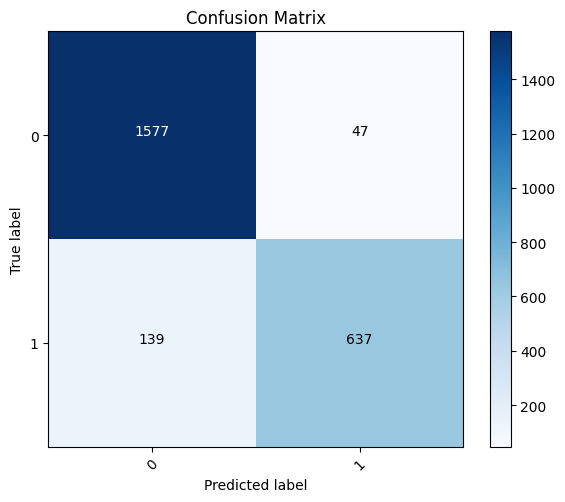

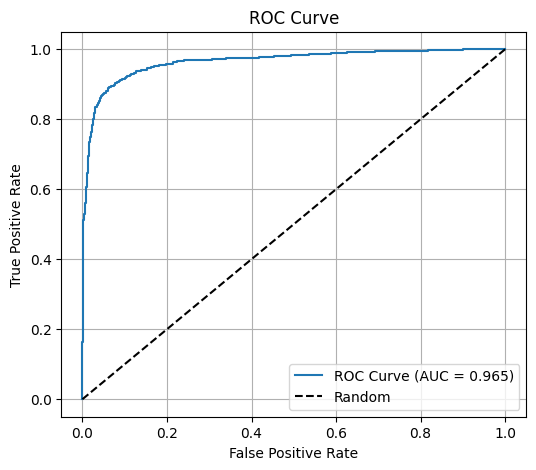

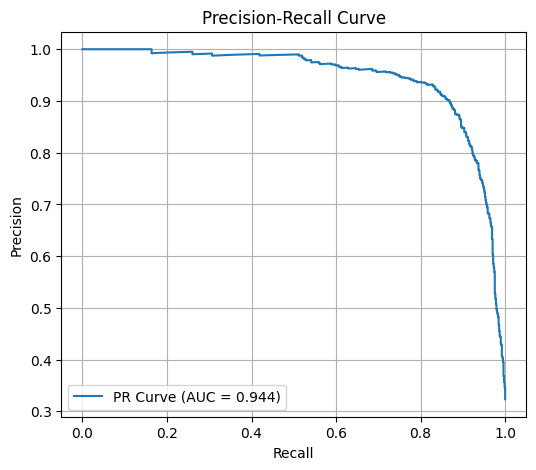


ПОЯСНЕНИЕ МЕТРИК:
- Accuracy: общая точность
- F1: баланс precision и recall — ключевая метрика для бинарной задачи.
- ROC-AUC: показывает качество модели по всем порогам — хорош для сравнения моделей.
- PR-AUC: лучше отражает качество на несбалансированных данных — особенно если интересует редкий класс.


In [16]:
model = gs_rf.best_estimator_  

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("=== МЕТРИКИ КАЧЕСТВА ===")

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.4f}")

auc_roc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {auc_roc:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))


# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
classes = unique_labels(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# Наносим значения в ячейки
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

# 2. ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_roc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# 3. PR Curve (Precision-Recall) — особенно полезна при дисбалансе!
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

# Кратко объясняем выбор метрик:
print("\n" + "="*50)
print("ПОЯСНЕНИЕ МЕТРИК:")
print("="*50)
print("- Accuracy: общая точность")
print("- F1: баланс precision и recall — ключевая метрика для бинарной задачи.")
print("- ROC-AUC: показывает качество модели по всем порогам — хорош для сравнения моделей.")
print("- PR-AUC: лучше отражает качество на несбалансированных данных — особенно если интересует редкий класс.")

DecisionTree: ROC-AUC = 0.9012
RandomForest: ROC-AUC = 0.9648
AdaBoost: ROC-AUC = 0.8994
Stacking: ROC-AUC = 0.9666

Лучшая модель: Stacking (ROC-AUC = 0.9666)

=== Permutation Importance (top-10 признаков) ===
Топ-10 признаков по важности:
1. num19                |   0.0636 ± 0.0011
2. num18                |   0.0587 ± 0.0042
3. num07                |   0.0264 ± 0.0016
4. num20                |   0.0163 ± 0.0015
5. num04                |   0.0129 ± 0.0009
6. num01                |   0.0096 ± 0.0013
7. num24                |   0.0089 ± 0.0006
8. num08                |   0.0079 ± 0.0008
9. num17                |   0.0075 ± 0.0005
10. num22                |   0.0067 ± 0.0010


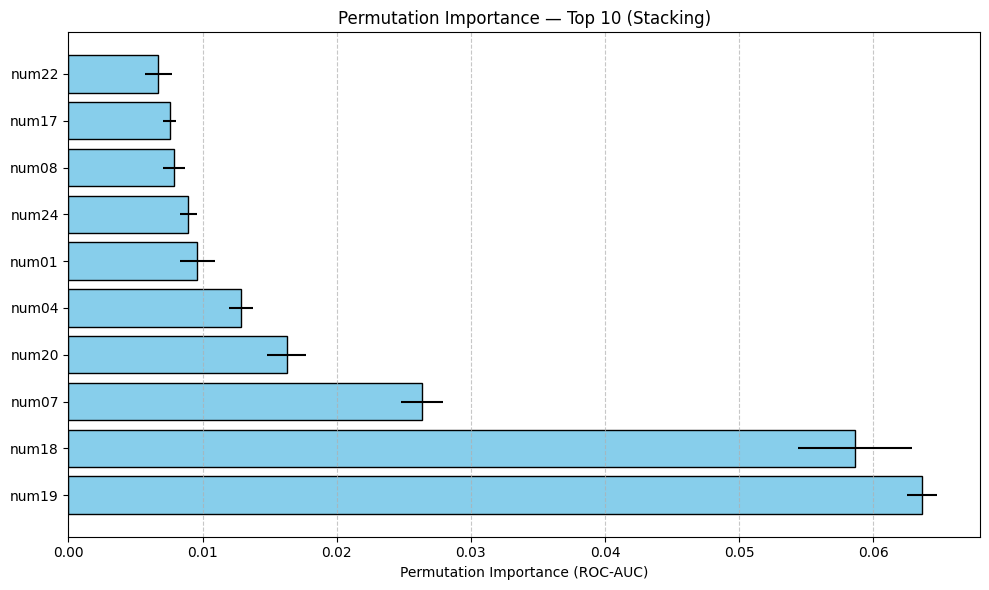

In [17]:
models = {
    'DecisionTree': gs_dt,
    'RandomForest': gs_rf,
    'AdaBoost': gs_ada,
    'Stacking': stack 
}

best_model_name = None
best_auc = -1
best_model = None

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_proba)
    print(f"{name}: ROC-AUC = {auc_score:.4f}")
    if auc_score > best_auc:
        best_auc = auc_score
        best_model_name = name
        best_model = model

print(f"\nЛучшая модель: {best_model_name} (ROC-AUC = {best_auc:.4f})")

print("\n=== Permutation Importance (top-10 признаков) ===")

perm_importance = permutation_importance(
    best_model, X_test, y_test, 
    n_repeats=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=1
)

sorted_idx = perm_importance.importances_mean.argsort()[::-1]  # от большего к меньшему
top_n = 10
top_features = X.columns[sorted_idx][:top_n]
top_importances = perm_importance.importances_mean[sorted_idx][:top_n]
top_std = perm_importance.importances_std[sorted_idx][:top_n]

print("Топ-10 признаков по важности:")
for i, (feat, imp, std) in enumerate(zip(top_features, top_importances, top_std)):
    print(f"{i+1}. {feat:<20} | {imp:>8.4f} ± {std:>6.4f}")

plt.figure(figsize=(10, 6))
y_pos = np.arange(len(top_features))
plt.barh(y_pos, top_importances, xerr=top_std, color='skyblue', edgecolor='black')
plt.yticks(y_pos, top_features)
plt.xlabel('Permutation Importance (ROC-AUC)')
plt.title(f'Permutation Importance — Top 10 ({best_model_name})')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Лучшей моделью по ROC-AUC на тестовой выборке оказался StackingClassifier (0.9668) — он незначительно превзошёл RandomForest (0.9648) и значительно обогнал DecisionTree (0.8973) и AdaBoost (0.8994). Это говорит о том, что комбинирование моделей дало прирост качества, особенно в условиях умеренного дисбаланса.

In [22]:
# --- 1. ФИНАЛЬНЫЙ СБОР МОДЕЛЕЙ ---
# Убедись, что все эти переменные (dummy, lr_pipeline и т.д.) обучены выше
all_models = {
    'Dummy': dummy,
    'LogisticRegression': lr_pipeline,
    'DecisionTree': gs_dt.best_estimator_,
    'RandomForest': gs_rf.best_estimator_,
    'Boosting': gs_ada.best_estimator_,
    'Stacking': stack
}

# --- 2. РАСЧЕТ МЕТРИК И ВЫБОР ЛУЧШЕЙ ---
metrics_dict = {}
best_roc_auc = -1
best_model_name = None
best_model_obj = None

print("=== ФИНАЛЬНОЕ СРАВНЕНИЕ НА TEST ===")

for name, model in all_models.items():
    y_pred = model.predict(X_test)
    
    # Считаем ROC-AUC (с обработкой моделей без predict_proba)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc_score = roc_auc_score(y_test, y_proba)
    else:
        auc_score = 0.5 
            
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='binary') # или 'macro' если классов > 2
    
    metrics_dict[name] = {
        'accuracy': round(float(acc), 4),
        'f1_score': round(float(f1), 4),
        'roc_auc': round(float(auc_score), 4)
    }
    
    print(f"{name:<20} | ROC-AUC: {auc_score:.4f} | F1: {f1:.4f}")

    # Обновляем лучшую модель
    if auc_score > best_roc_auc:
        best_roc_auc = auc_score
        best_model_name = name
        best_model_obj = model

# --- 3. СОХРАНЕНИЕ АРТЕФАКТОВ ---
import os
import json
import joblib

# Путь согласно структуре задания
artifacts_dir = "artifacts" 
os.makedirs(artifacts_dir, exist_ok=True)
figures_dir = os.path.join(artifacts_dir, "figures")
os.makedirs(figures_dir, exist_ok=True)

# Сохраняем metrics_test.json
with open(os.path.join(artifacts_dir, "metrics_test.json"), "w") as f:
    json.dump(metrics_dict, f, indent=4)

# Сохраняем search_summaries.json (только для моделей с GridSearch)
search_summaries = {
    'DecisionTree': {'best_params': gs_dt.best_params_, 'best_cv_score': gs_dt.best_score_},
    'RandomForest': {'best_params': gs_rf.best_params_, 'best_cv_score': gs_rf.best_score_},
    'AdaBoost': {'best_params': gs_ada.best_params_, 'best_cv_score': gs_ada.best_score_}
}
with open(os.path.join(artifacts_dir, "search_summaries.json"), "w") as f:
    json.dump(search_summaries, f, indent=4)

# Сохраняем лучшую модель
joblib.dump(best_model_obj, os.path.join(artifacts_dir, "best_model.joblib"))

# Сохраняем мета-данные (с защитой от TypeError через str)
safe_params = {k: str(v) for k, v in best_model_obj.get_params().items()}
meta_info = {
    "model_name": best_model_name,
    "metrics": metrics_dict[best_model_name],
    "params": safe_params
}
with open(os.path.join(artifacts_dir, "best_model_meta.json"), "w") as f:
    json.dump(meta_info, f, indent=4)

print(f"\nВсе артефакты сохранены! Лучшая модель: {best_model_name}")

=== ФИНАЛЬНОЕ СРАВНЕНИЕ НА TEST ===
Dummy                | ROC-AUC: 0.5000 | F1: 0.0000
LogisticRegression   | ROC-AUC: 0.8747 | F1: 0.7076
DecisionTree         | ROC-AUC: 0.9012 | F1: 0.7792
RandomForest         | ROC-AUC: 0.9648 | F1: 0.8726
Boosting             | ROC-AUC: 0.8994 | F1: 0.7234
Stacking             | ROC-AUC: 0.9666 | F1: 0.8874

Все артефакты сохранены! Лучшая модель: Stacking
